# Rollout Length Analysis 
Fundamental characterization of token-length distributions across **rollout**, **group**, and **sample** levels.  \nData: `qwen3-4b` on MATH-500, two budget/group-size configs.---"

In [33]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"Math500_32k": "#8d99ae", "Math500_16k": "#fca311"}

ROLLOUT_DIR = Path("/fs/nexus-scratch/yangfc/cmsc828g-finalproj/rollouts")
FILES = {
    "Math500_32k": ROLLOUT_DIR / "inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl",
    "Math500_16k": ROLLOUT_DIR / "inference_qwen3-4b_math500_G8_B16384_chunk0.jsonl",
}

## 1. Data Loading\nStream both JSONL files into a flat rollout-level DataFrame."

In [34]:
rows = []
for config, path in FILES.items():
    with open(path) as f:
        for line in f:
            rec = json.loads(line)
            for out in rec["method_output"]["outputs"]:
                rows.append({
                    "config":          config,
                    "sample_idx":      rec["sample_idx"],
                    "group_idx":       rec["group_idx"],
                    "rollout_idx":     out["index"],
                    "n_tokens":        len(out["token_ids"]),
                    "finish_reason":   out["finish_reason"] or "stop",
                    "generation_time": rec["generation_time"],
                    "B":               rec["B"],
                    "G":               rec["G"],
                })

df = pd.DataFrame(rows)
print(f"Total rollouts loaded: {len(df):,}")
df.head(3)

Total rollouts loaded: 192,000


,config,sample_idx,group_idx,rollout_idx,n_tokens,finish_reason,generation_time,B,G
0,Math500_32k,0,0,0,1537,stop,30.93102,32768,4
1,Math500_32k,0,0,1,1775,stop,30.93102,32768,4
2,Math500_32k,0,0,2,1968,stop,30.93102,32768,4


## 2. Dataset Overview"

In [9]:
overview_rows = []
for config, g in df.groupby("config"):
    n_rollouts   = len(g)
    n_samples    = g["sample_idx"].nunique()
    n_groups     = g.groupby(["sample_idx", "group_idx"]).ngroups
    groups_per_s = n_groups / n_samples
    budget_hit   = (g["finish_reason"] == "length").sum()
    overview_rows.append({
        "config":            config,
        "G":                 g["G"].iloc[0],
        "B":                 g["B"].iloc[0],
        "total_rollouts":    n_rollouts,
        "unique_samples":    n_samples,
        "total_groups":      n_groups,
        "groups/sample":     round(groups_per_s, 1),
        "budget_hit":        budget_hit,
        "budget_hit_%":      round(100 * budget_hit / n_rollouts, 2),
    })

overview_df = pd.DataFrame(overview_rows).set_index("config")
print(overview_df.to_string())

             G      B  total_rollouts  unique_samples  total_groups  groups/sample  budget_hit  budget_hit_%
config                                                                                                      
Math500_16k  8  16384          128000             500         16000           32.0        5217          4.08
Math500_32k  4  32768           64000             500         16000           32.0         238          0.37


## 3. Rollout-Level Length Distribution\nEach point = one individual generation (token count)."

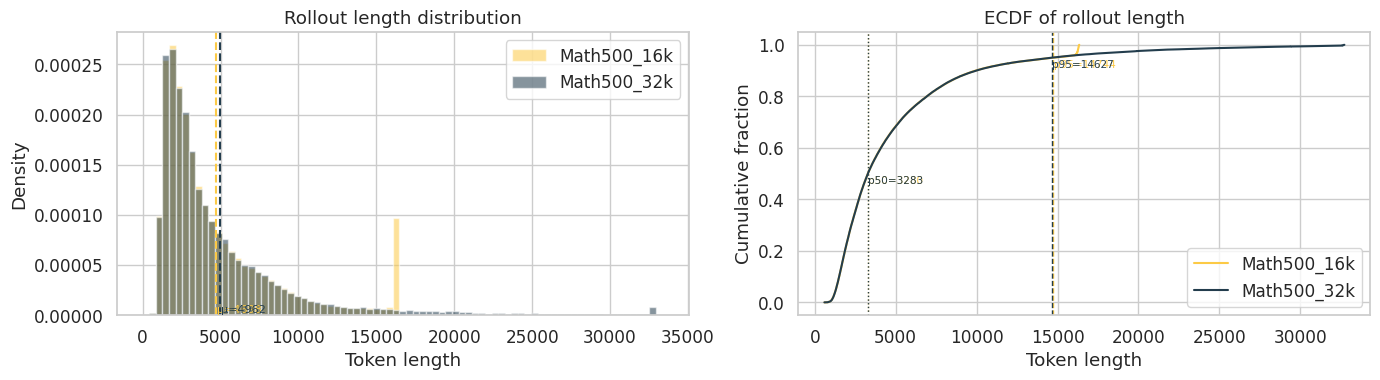

                count    mean     std    min      5%     25%     50%     75%      95%      99%      max
config                                                                                                 
Math500_16k  128000.0  4698.0  3792.5  606.0  1302.0  2058.0  3280.0  5961.0  14744.0  16292.0  16344.0
Math500_32k   64000.0  4961.6  4814.8  593.0  1306.0  2058.0  3283.0  5966.0  14627.1  26593.0  32721.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: histogram (density) ---
ax = axes[0]
bins = np.linspace(0, df["n_tokens"].max() * 1.02, 80)
for cfg, g in df.groupby("config"):
    ax.hist(g["n_tokens"], bins=bins, density=True, alpha=0.55,
            color=PALETTE[cfg], label=cfg)
    mu, sd = g["n_tokens"].mean(), g["n_tokens"].std()
    ax.axvline(mu, color=PALETTE[cfg], lw=1.5, ls="--")
    ax.text(mu + 50, ax.get_ylim()[1] * 0.01, f"μ={mu:.0f}", color=PALETTE[cfg], fontsize=8)

ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.set_title("Rollout length distribution")
ax.legend()

# --- Right: ECDF ---
ax = axes[1]
for cfg, g in df.groupby("config"):
    vals = np.sort(g["n_tokens"].values)
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, ecdf, color=PALETTE[cfg], lw=1.5, label=cfg)
    for pct, ls in [(0.50, ":"), (0.95, "--")]:
        v = np.quantile(vals, pct)
        ax.axvline(v, color=PALETTE[cfg], lw=1, ls=ls)
        ax.text(v + 30, pct - 0.04, f"p{int(pct*100)}={v:.0f}", fontsize=7.5, color=PALETTE[cfg])

ax.set_xlabel("Token length")
ax.set_ylabel("Cumulative fraction")
ax.set_title("ECDF of rollout length")
ax.legend()

plt.tight_layout()
plt.savefig("rollout_length_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats table
print(df.groupby("config")["n_tokens"].describe(percentiles=[.05,.25,.5,.75,.95,.99]).round(1).to_string())

## 4. Budget Utilization\nHow close do rollouts get to the max-token ceiling?"

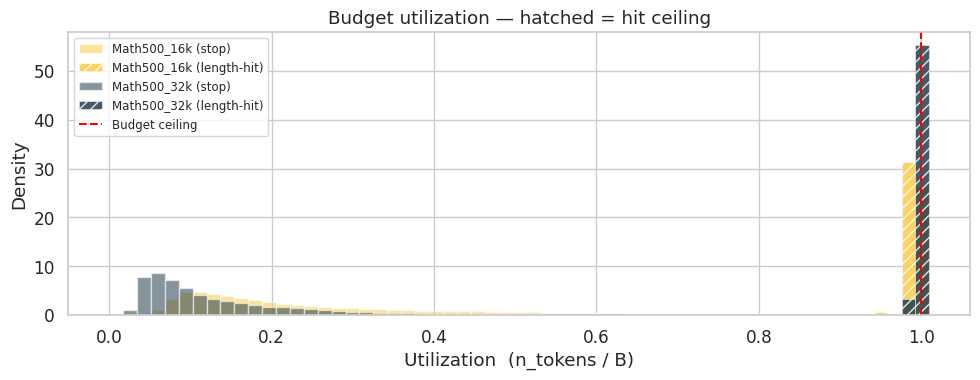

In [17]:
df["utilization"] = df["n_tokens"] / df["B"]

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1.01, 60)

for cfg, g in df.groupby("config"):
    stopped = g[g["finish_reason"] != "length"]["utilization"]
    truncated = g[g["finish_reason"] == "length"]["utilization"]
    ax.hist(stopped,   bins=bins, density=True, alpha=0.55, color=PALETTE[cfg], label=f"{cfg} (stop)")
    ax.hist(truncated, bins=bins, density=True, alpha=0.85, color=PALETTE[cfg],
            label=f"{cfg} (length-hit)", hatch="///", edgecolor="white", linewidth=0.4)

ax.axvline(1.0, color="red", lw=1.5, ls="--", label="Budget ceiling")
ax.set_xlabel("Utilization  (n_tokens / B)")
ax.set_ylabel("Density")
ax.set_title("Budget utilization — hatched = hit ceiling")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig("budget_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Group-Level Aggregates\nOne group = G rollouts dispatched together in one vLLM call.  \nThe **group max** is the throughput bottleneck (batch finishes when the longest sequence does)."

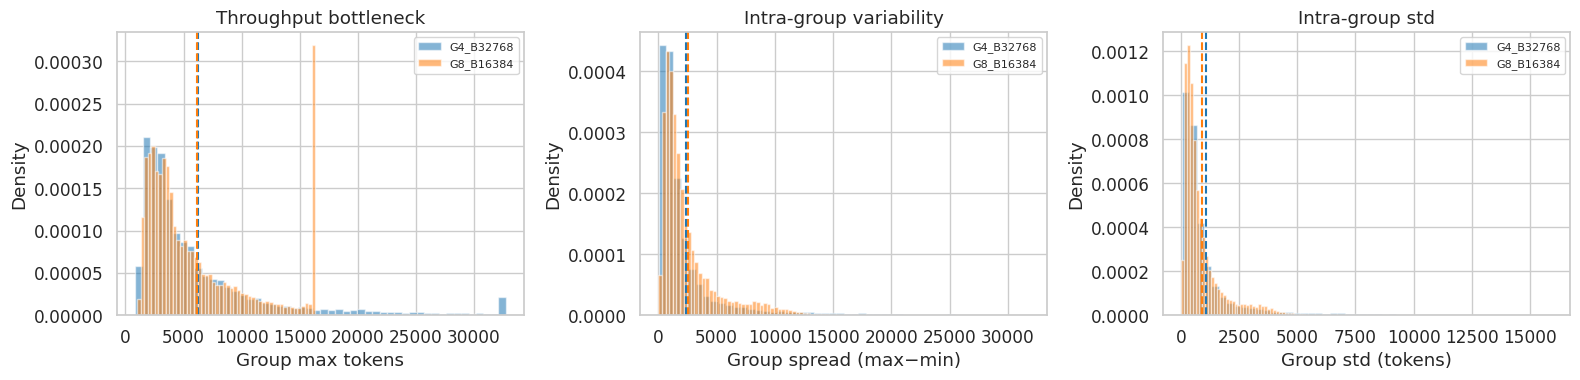

          group_max                                                                  group_min                                                                  group_sum                                                                          group_spread                                                               group_std                                                             
              count    mean     std    min     25%     50%     75%      95%      max     count    mean     std    min     25%     50%     75%      95%      max     count     mean      std     min      25%      50%      75%       95%       max        count    mean     std   min    25%     50%     75%     95%      max     count    mean     std   min    25%    50%     75%     95%      max
config                                                                                                                                                                                                                        

In [ ]:
grp = (df.groupby(["config", "sample_idx", "group_idx"])["n_tokens"]
         .agg(group_max="max", group_min="min", group_sum="sum", group_std="std", group_mean="mean")
         .reset_index())
grp["group_spread"] = grp["group_max"] - grp["group_min"]

# Attach generation_time (same for all rollouts in a group)
gt = df.drop_duplicates(["config", "sample_idx", "group_idx"])[
    ["config", "sample_idx", "group_idx", "generation_time"]]
grp = grp.merge(gt, on=["config", "sample_idx", "group_idx"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ("group_max",    "Group max tokens",    "Throughput bottleneck"),
    ("group_spread", "Group spread (max−min)", "Intra-group variability"),
    ("group_std",    "Group std (tokens)",  "Intra-group std"),
]
for ax, (col, xlabel, title) in zip(axes, metrics):
    for cfg, g in grp.groupby("config"):
        vals = g[col].dropna()
        ax.hist(vals, bins=50, density=True, alpha=0.55, color=PALETTE[cfg], label=cfg)
        ax.axvline(vals.mean(), color=PALETTE[cfg], lw=1.5, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("group_level_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric summary
print(grp.groupby("config")[["group_max","group_min","group_sum","group_spread","group_std"]]
        .describe(percentiles=[.25,.5,.75,.95]).round(1).to_string())

## 6. Sample-Level Aggregates\nCollapse all rollouts for each `sample_idx`.  \n**Per-sample mean** = proxy for problem difficulty; **per-sample std** = model consistency on that problem."

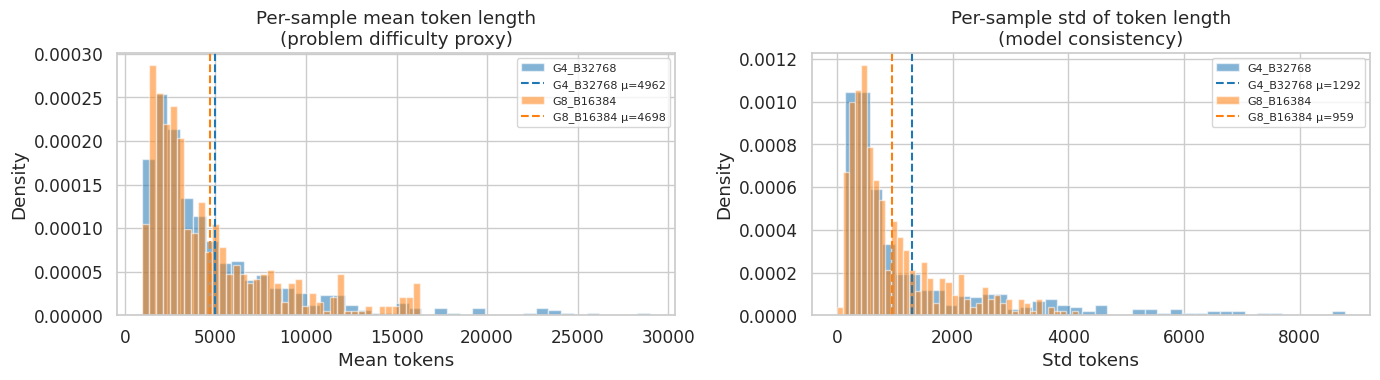

          sample_mean                                                                  sample_std                                                              sample_min                                                                 sample_max                                                                     sample_spread                                                                 
                count    mean     std    min     25%     50%     75%      95%      max      count    mean     std    min    25%    50%     75%     95%     max      count    mean     std    min     25%     50%     75%     95%      max      count     mean     std     min     25%     50%      75%      95%      max         count    mean     std    min     25%     50%     75%      95%      max
config                                                                                                                                                                                                                  

In [ ]:
smp = (df.groupby(["config", "sample_idx"])["n_tokens"]
         .agg(sample_mean="mean", sample_std="std", sample_min="min",
              sample_max="max", sample_spread=lambda x: x.max() - x.min())
         .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, title, xlabel) in zip(axes, [
    ("sample_mean", "Per-sample mean token length\n(problem difficulty proxy)", "Mean tokens"),
    ("sample_std",  "Per-sample std of token length\n(model consistency)",       "Std tokens"),
]):
    for cfg, g in smp.groupby("config"):
        vals = g[col].dropna()
        ax.hist(vals, bins=40, density=True, alpha=0.55, color=PALETTE[cfg], label=cfg)
        ax.axvline(vals.mean(), color=PALETTE[cfg], lw=1.5, ls="--",
                   label=f"{cfg} μ={vals.mean():.0f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sample_level_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(smp.groupby("config")[["sample_mean","sample_std","sample_min","sample_max","sample_spread"]]
        .describe(percentiles=[.25,.5,.75,.95]).round(1).to_string())

## 7. Generation Time vs. Group Metrics\nVerify that `group_max` (not `group_sum`) drives wall-clock time — confirms vLLM's max-length batching behavior."

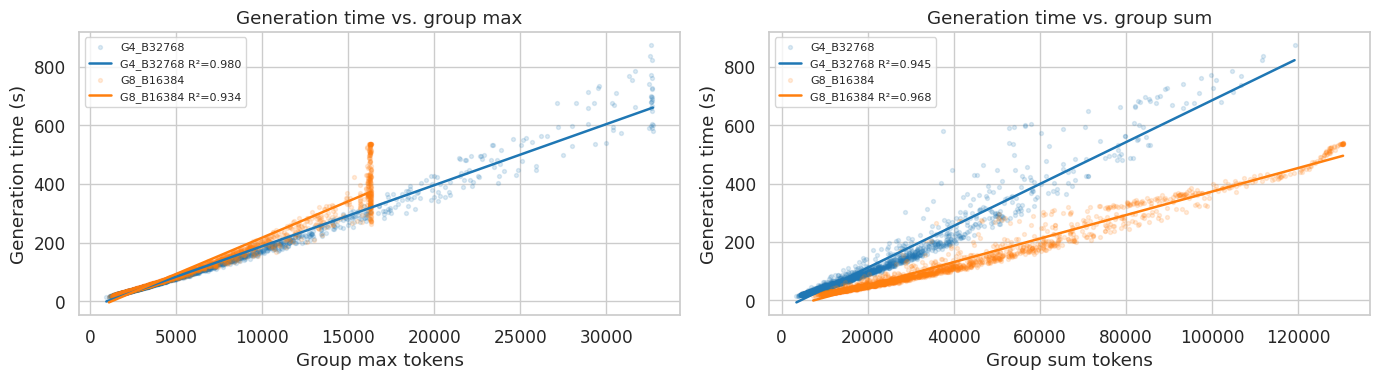

In [ ]:
from scipy.stats import linregress

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (xcol, xlabel, title) in zip(axes, [
    ("group_max", "Group max tokens", "Generation time vs. group max"),
    ("group_sum", "Group sum tokens", "Generation time vs. group sum"),
]):
    for cfg, g in grp.groupby("config"):
        # subsample for readability
        sub = g.sample(min(2000, len(g)), random_state=42)
        x, y = sub[xcol].values, sub["generation_time"].values
        ax.scatter(x, y, alpha=0.15, s=8, color=PALETTE[cfg], label=cfg)
        slope, intercept, r, *_ = linregress(x, y)
        xline = np.array([x.min(), x.max()])
        ax.plot(xline, slope * xline + intercept, color=PALETTE[cfg], lw=1.8,
                label=f"{cfg} R²={r**2:.3f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Generation time (s)")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("gentime_vs_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Cross-Config Comparison\nSide-by-side violin + summary stats table."

/tmp/ipykernel_2337358/1215958198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="config", y="n_tokens", palette=PALETTE,


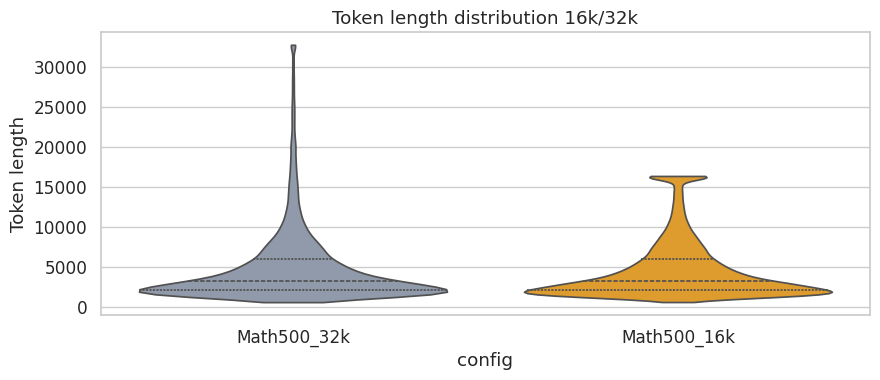

               mean     std  min    max      p5     p25     p50     p75      p95      p99  budget_hit_%
config                                                                                                 
Math500_16k  4698.0  3792.5  606  16344  1302.0  2058.0  3280.0  5961.0  14744.0  16292.0          4.08
Math500_32k  4961.6  4814.8  593  32721  1306.0  2058.0  3283.0  5966.0  14627.1  26593.0          0.37


/tmp/ipykernel_2337358/1215958198.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  budget_hit_pct = df.groupby("config").apply(


In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(data=df, x="config", y="n_tokens", palette=PALETTE,
               inner="quartile", cut=0, ax=ax)
# ax.set_xlabel("Config")
ax.set_ylabel("Token length")
ax.set_title("Token length distribution 16k/32k")
plt.tight_layout()
plt.savefig("config_violin.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats table
pcts = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
summary = (df.groupby("config")["n_tokens"]
             .agg(mean="mean", std="std", min="min", max="max",
                  **{f"p{int(p*100)}": lambda x, p=p: x.quantile(p) for p in pcts})
             .round(1))
budget_hit_pct = df.groupby("config").apply(
    lambda g: round(100 * (g["finish_reason"] == "length").mean(), 2))
summary["budget_hit_%"] = budget_hit_pct
print(summary.to_string())

## 9. Per-Request Length Diversity (10 sampled requests)\nRandom sample of 10 questions (seed=888). Each violin = all rollouts for that question — shows how diverse token lengths are *within* a single prompt across independent rollouts."

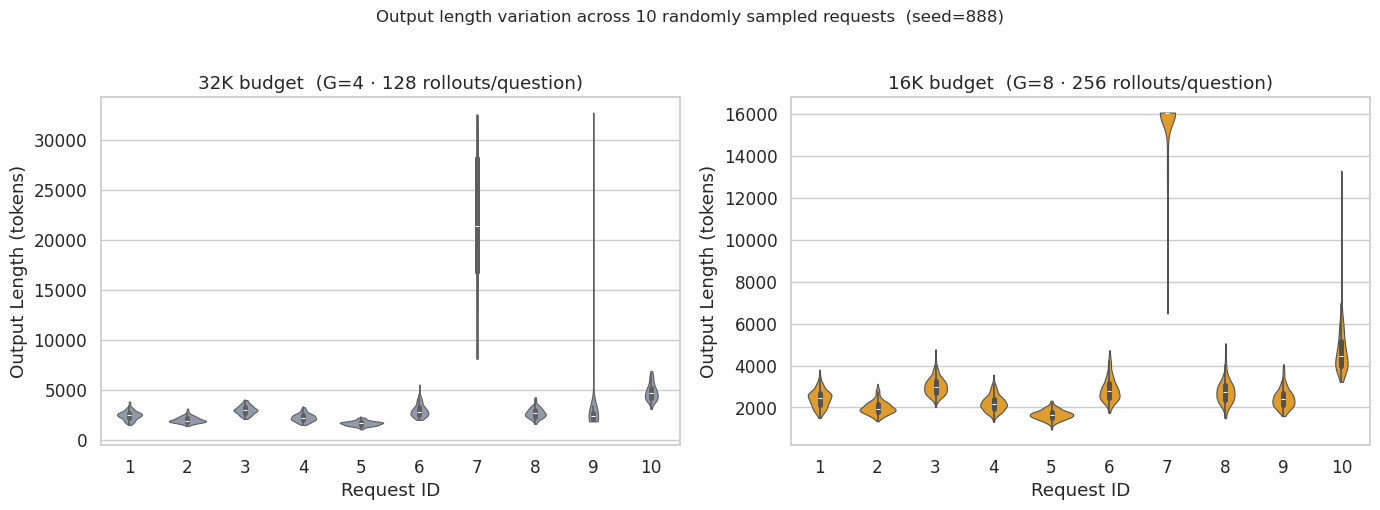

In [44]:
rng = np.random.default_rng(8)
all_samples = sorted(df["sample_idx"].unique())
sampled_10  = sorted(rng.choice(all_samples, size=10, replace=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

configs_ordered = ["Math500_32k", "Math500_16k"]
titles = [
    "32K budget  (G=4 · 128 rollouts/question)",
    "16K budget  (G=8 · 256 rollouts/question)",
]

for ax, cfg, title in zip(axes, configs_ordered, titles):
    sub = df[(df["config"] == cfg) & (df["sample_idx"].isin(sampled_10))].copy()
    idx_map = {s: i + 1 for i, s in enumerate(sampled_10)}
    sub["Request ID"] = sub["sample_idx"].map(idx_map)

    sns.violinplot(
        data=sub, x="Request ID", y="n_tokens",
        color=PALETTE[cfg], inner="box",
        cut=0, width=0.75, linewidth=0.8, ax=ax,
    )
    ax.set_xlabel("Request ID")
    ax.set_ylabel("Output Length (tokens)")
    ax.set_title(title)

fig.suptitle(
    "Output length variation across 10 randomly sampled requests  (seed=888)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig("per_request_violin.png", dpi=150, bbox_inches="tight")
plt.show()

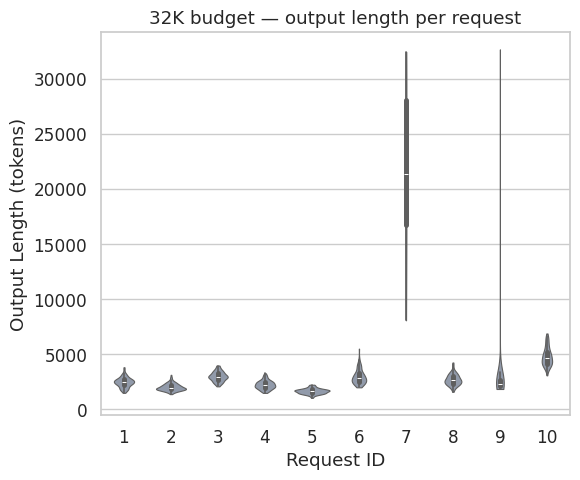

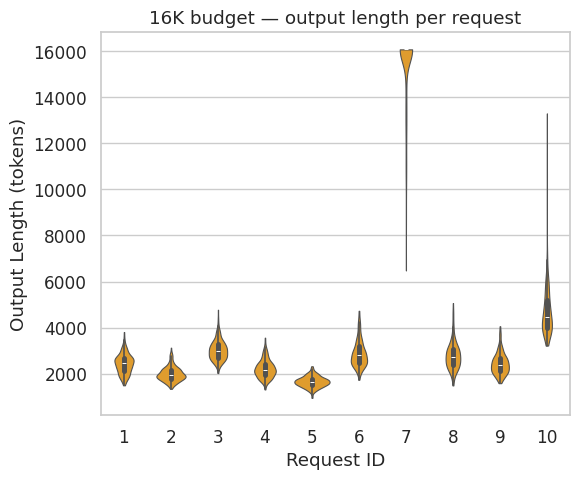

In [45]:
# Separate full-page plots per config
for cfg in ["Math500_32k", "Math500_16k"]:
    sub = df[(df["config"] == cfg) & (df["sample_idx"].isin(sampled_10))].copy()
    idx_map = {s: i + 1 for i, s in enumerate(sampled_10)}
    sub["Request ID"] = sub["sample_idx"].map(idx_map)

    budget = "32K" if "32k" in cfg else "16K"
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.violinplot(
        data=sub, x="Request ID", y="n_tokens",
        color=PALETTE[cfg], inner="box",
        cut=0, width=0.75, linewidth=0.8, ax=ax,
    )
    ax.set_xlabel("Request ID")
    ax.set_ylabel("Output Length (tokens)")
    ax.set_title(f"{budget} budget — output length per request")
    plt.tight_layout()
    plt.savefig(f"per_request_violin_{cfg}.png", dpi=150, bbox_inches="tight")
    plt.show()